## Load Dataset

In [ ]:
import pandas as pd
import numpy as np  
import math
from sklearn.cluster import KMeans
from scipy.spatial.distance import euclidean
from utils.kmean_evalution import evaluate_kmeans_overlap
from structures.grid import Grid, DensityGrid
from structures.r_tree_analyzer import RTreeSpatialAnalyzer



%matplotlib inline

import matplotlib.pyplot as plt

In [ ]:
csv_data = pd.read_csv("datasets/points.csv")
latitudes = csv_data["normLatitude"]
longitudes = csv_data["normLongitude"]
maxLatitude = latitudes.max()
minLatitude = latitudes.min()
minLatitude = math.floor(minLatitude)
maxLatitude = math.ceil(maxLatitude)

maxLongitude = longitudes.max()
maxLongitude = math.ceil(maxLongitude)

minLongtitude = longitudes.min()
minLongtitude = math.floor(minLongtitude)

points_array = np.column_stack((longitudes, latitudes))
# initiate KMEANS
kmeans_data = csv_data[["normLatitude", "normLongitude"]].to_numpy()


## KMEANS Evaluation

In [ ]:
overlap_score, labels, centers, radii = evaluate_kmeans_overlap(
    kmeans_data, n_clusters=7
)
print("KMEANS Score:", overlap_score)

KMEANS Score: 3.6810442012311464


## Grid Evalution

In [ ]:
grid = Grid(
        xmin=minLongtitude, ymin=minLatitude, xmax=maxLongitude, ymax=maxLatitude, m=20
    )
    # assign points to grid
grid.fit(zip(csv_data["normLongitude"], csv_data["normLatitude"]))
    
print(f"Grid Score: {grid.compute_grid_overlap()}")

Grid Score: 0.24152941354751312


## Density Based Grid

In [ ]:
density_grid = DensityGrid(
    xmin=minLongtitude, ymin=minLatitude, xmax=maxLongitude, ymax=maxLatitude, m=20
)
# assign points to grid
density_grid.fit(zip(csv_data["normLongitude"], csv_data["normLatitude"]))
print(f"Density Grid: {density_grid.compute_grid_overlap()}")

Density Grid: 0.28531906827524106


## R Tree Evaluation

In [ ]:
csv_file_path = "./datasets/skewed_coords.csv"
analyzer = RTreeSpatialAnalyzer()
if analyzer.load_data_from_csv(csv_file_path):
    total_overlap = analyzer.compute_overlap()
    print(f"Total computed overlap area among circles: {total_overlap:.2f}")
    # analyzer.visualize()

R-tree built with 1000 entries.
Total computed overlap area among circles: 33.58


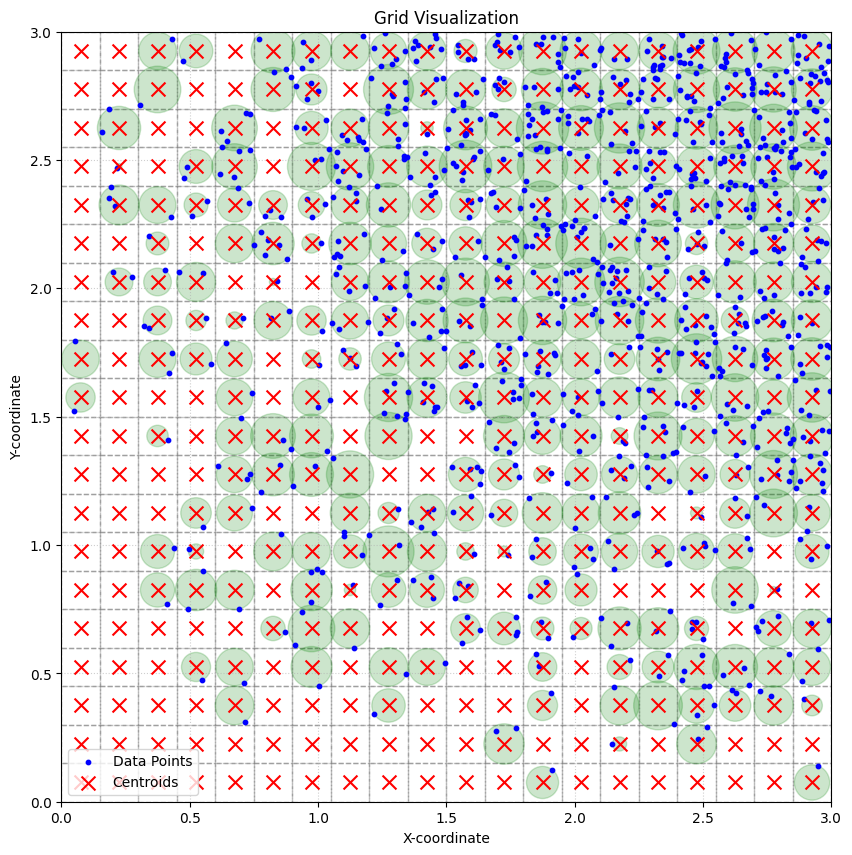

In [ ]:
grid.visualize_grid()

In [ ]:
analyzer.visualize()

In [ ]:
# density_grid.visualize_grid()

In [ ]:
kmeans_overlap = overlap_score  
grid_overlap = grid.compute_grid_overlap()
density_grid_overlap = density_grid.compute_grid_overlap()
r_tree_overlap = total_overlap

algorithm_details = [
    {
        "Algorithm": "KMEANS",
        "Overlap Score": kmeans_overlap,
        "Parameters": "n_clusters=7"
    },
    {
        "Algorithm": "Grid",
        "Overlap Score": grid_overlap,
        "Parameters": "m=20"
    },
    {
        "Algorithm": "Density Grid",
        "Overlap Score": density_grid_overlap,
        "Parameters": "m=20"
    },
    {
        "Algorithm": "R-Tree",
        "Overlap Score": r_tree_overlap,
        "Parameters": "-"
    }
]

import pandas as pd
comparison_df = pd.DataFrame(algorithm_details)
display(comparison_df)

,Algorithm,Overlap Score,Parameters
0,KMEANS,3.681044,n_clusters=7
1,Grid,0.241529,m=20
2,Density Grid,0.285319,m=20
3,R-Tree,33.584261,-
